In [2]:
import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation
print("[OK] Imported evaluate_segmentation")

[OK] Imported evaluate_segmentation


In [7]:
RUNS_ROOT = Path("../inference/clipseg_cloudsen12plus_fft_low_data").expanduser().resolve()

OUT_ROOT = Path("../inference/clipseg_cloudsen12plus_fft_low_data").expanduser().resolve()

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").expanduser().resolve()


MODEL = "clipseg"
DATASET = "cloudsen12plus"


GT_KEY = "mask"
PRED_KEY = "mask"
GT_EXT = ".npz"
PRED_EXT = ".npz"

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

IGNORE_INDEX = None
STRICT = True
FORCE = False

BUCKETS = ["pct_2.5"]

EXISTING_LOW_DATA_CSV = Path("../inference/clipseg_cloudsen12plus_fft_low_data/fft_low_data_ladder.csv").expanduser().resolve()
print("RUNS_ROOT:", RUNS_ROOT, "exists:", RUNS_ROOT.exists())
print("OUT_ROOT :", OUT_ROOT, "exists:", OUT_ROOT.exists())
print("GT_DIR   :", GT_DIR, "exists:", GT_DIR.exists())
print("Existing low-data CSV:", EXISTING_LOW_DATA_CSV, "exists:", EXISTING_LOW_DATA_CSV.exists())

RUNS_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data exists: True
OUT_ROOT : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data exists: True
GT_DIR   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
Existing low-data CSV: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data/fft_low_data_ladder.csv exists: True


In [8]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

def parse_pct_value(folder_name: str) -> float:
    """
    pct_10  -> 10.0
    pct_0.1 -> 0.1
    """
    m = re.match(r"pct_(\d+(\.\d+)?)$", folder_name)
    if not m:
        raise ValueError(f"Bad pct folder name: {folder_name}")
    return float(m.group(1))

def sanitize_stage(s: str) -> str:
    s = s.strip()
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", s)

def pick_latest_checkpoint(seed_dir: Path) -> Path | None:
    ckpts = list(seed_dir.glob("checkpoint-*"))
    if not ckpts:
        return None
    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1
    ckpts.sort(key=step)
    return ckpts[-1]

def resolve_pred_dir(seed_dir: Path, pred_ext: str) -> Path:
    ckpt = pick_latest_checkpoint(seed_dir)
    if ckpt is not None:
        cand = ckpt / "masks"
        if cand.is_dir() and any(cand.glob(f"*{pred_ext}")):
            return cand

    cand2 = seed_dir / "masks"
    if cand2.is_dir() and any(cand2.glob(f"*{pred_ext}")):
        return cand2

    candidates = [p for p in seed_dir.rglob("masks") if p.is_dir()]
    if candidates:
        candidates.sort(key=lambda p: len(list(p.glob(f"*{pred_ext}"))))
        best = candidates[-1]
        if any(best.glob(f"*{pred_ext}")):
            return best

    if any(seed_dir.glob(f"*{pred_ext}")):
        return seed_dir

    raise FileNotFoundError(f"Could not find prediction masks under: {seed_dir}")

def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)

def read_aggregate_row(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row in {csv_path}")
    return agg.iloc[0]


In [9]:
from pathlib import Path

if not RUNS_ROOT.exists():
    raise FileNotFoundError(f"RUNS_ROOT not found: {RUNS_ROOT}")
if not GT_DIR.exists():
    raise FileNotFoundError(f"GT_DIR not found: {GT_DIR}")

OUT_ROOT.mkdir(parents=True, exist_ok=True)

done = 0
skipped = 0
failed = 0

for pct_folder in BUCKETS:
    bucket_dir = (RUNS_ROOT / pct_folder).resolve()
    if not bucket_dir.is_dir():
        print(f"[WARN] Missing bucket folder: {bucket_dir} (skipping)")
        continue

    out_bucket_dir = (OUT_ROOT / pct_folder).resolve()
    out_bucket_dir.mkdir(parents=True, exist_ok=True)

    seed_dirs = sorted([s for s in bucket_dir.glob("seed_*") if s.is_dir()])
    print(f"\n[INFO] {pct_folder}: seeds={len(seed_dirs)}")

    for seed_dir in seed_dirs:
        seed_name = seed_dir.name

        miou_dst = out_bucket_dir / f"{seed_name}_miou.csv"
        cm_dst   = out_bucket_dir / f"{seed_name}_cm.csv"

        if (not FORCE) and miou_dst.exists() and cm_dst.exists():
            skipped += 1
            continue

        try:
            pred_dir = resolve_pred_dir(seed_dir, PRED_EXT)
            stage = sanitize_stage(seed_name)

            result = evaluate_segmentation(
                gt_dir=GT_DIR,
                pred_dir=pred_dir,
                model=MODEL,
                dataset=DATASET,
                stage=stage,
                num_classes=NUM_CLASSES,
                class_names=CLASS_NAMES,
                run_root=out_bucket_dir,
                gt_key=GT_KEY,
                pred_key=PRED_KEY,
                gt_ext=GT_EXT,
                pred_ext=PRED_EXT,
                ignore_index=IGNORE_INDEX,
                strict=STRICT,
            )

            safe_rename(Path(result["miou_csv"]), miou_dst)
            safe_rename(Path(result["cm_csv"]), cm_dst)

            done += 1
            print(f"[OK] {pct_folder}/{seed_name}")

        except Exception as e:
            failed += 1
            print(f"[FAIL] {pct_folder}/{seed_name}: {e}")

print(f"\n[DONE] ran={done}, skipped={skipped}, failed={failed}")



[INFO] pct_2.5: seeds=10


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_2.5/seed_11


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_2.5/seed_111


...

[OK] pct_2.5/seed_77


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_2.5/seed_88


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_2.5/seed_99

[DONE] ran=10, skipped=0, failed=0


In [10]:
seed_records = []

for pct_folder in BUCKETS:
    out_bucket_dir = (OUT_ROOT / pct_folder).resolve()
    if not out_bucket_dir.is_dir():
        continue

    pct_val = parse_pct_value(pct_folder)

    miou_files = sorted(out_bucket_dir.glob("seed_*_miou.csv"))
    cm_files   = sorted(out_bucket_dir.glob("seed_*_cm.csv"))

    miou_map = {f.name.replace("_miou.csv",""): f for f in miou_files}
    cm_map   = {f.name.replace("_cm.csv",""): f for f in cm_files}

    seeds = sorted(set(miou_map.keys()) & set(cm_map.keys()))
    if not seeds:
        print(f"[WARN] No seed pairs in {out_bucket_dir}")
        continue

    for seed in seeds:
        miou_agg = read_aggregate_row(miou_map[seed])
        cm_agg   = read_aggregate_row(cm_map[seed])

        rec = {"pct": pct_val, "seed": seed, "bucket": pct_folder}

        for c in [c for c in miou_agg.index if c != "id"]:
            rec[c] = float(miou_agg[c])
        for c in [c for c in cm_agg.index if c != "id"]:
            rec[c] = int(cm_agg[c])

        seed_records.append(rec)

seed_df_new = pd.DataFrame(seed_records)
print("seed_df_new shape:", seed_df_new.shape)
display(seed_df_new.head())


seed_df_new shape: (10, 25)


,pct,seed,bucket,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow,cm_t0_p0,...,cm_t1_p2,cm_t1_p3,cm_t2_p0,cm_t2_p1,cm_t2_p2,cm_t2_p3,cm_t3_p0,cm_t3_p1,cm_t3_p2,cm_t3_p3
0,2.5,seed_11,pct_2.5,0.475163,0.772682,0.745103,0.687794,0.138194,0.329561,121315807,...,2433084,2741602,12090881,4331518,4044814,1517855,8099506,4966889,607544,10587764
1,2.5,seed_111,pct_2.5,0.459863,0.783349,0.762184,0.697260,0.060043,0.319966,125692035,...,785822,2499856,13273635,5645976,1441356,1624101,8471267,5351276,248485,10190675
2,2.5,seed_22,pct_2.5,0.465399,0.783830,0.764223,0.700427,0.068604,0.328340,123935691,...,972249,2617514,12804370,5505574,1677903,1997221,7507742,5600280,321713,10831968
3,2.5,seed_33,pct_2.5,0.457824,0.780592,0.759490,0.688399,0.064499,0.318910,124752518,...,925077,2715670,13048444,5763533,1545372,1627719,8562333,5385070,155785,10158515
4,2.5,seed_44,pct_2.5,0.466109,0.768287,0.744682,0.689895,0.122213,0.307644,118708500,...,1270910,2746578,10092824,6124987,3489567,2277690,7416786,5601649,501962,10741306


In [11]:
if seed_df_new.empty:
    raise RuntimeError("No new seed records found for the BUCKETS. Check OUT_ROOT and file names.")

metric_cols = [c for c in seed_df_new.columns if c not in ["pct","seed","bucket"] and not c.startswith("cm_")]
cm_cols     = [c for c in seed_df_new.columns if c.startswith("cm_")]

n_seeds = seed_df_new.groupby("pct")["seed"].nunique().to_frame("n_seeds")
metric_mean = seed_df_new.groupby("pct")[metric_cols].mean().add_suffix("_mean")
metric_std  = seed_df_new.groupby("pct")[metric_cols].std(ddof=1).add_suffix("_std").fillna(0.0)
cm_sum      = seed_df_new.groupby("pct")[cm_cols].sum().add_suffix("_sum")

pct_df_new = pd.concat([n_seeds, metric_mean, metric_std, cm_sum], axis=1).reset_index().sort_values("pct")
display(pct_df_new)

if EXISTING_LOW_DATA_CSV.exists():
    old = pd.read_csv(EXISTING_LOW_DATA_CSV)
    if "pct" not in old.columns:
        raise ValueError("Existing low_data_ladder.csv must have a 'pct' column")

    old["pct"] = old["pct"].astype(float)
    pct_df_new["pct"] = pct_df_new["pct"].astype(float)

    old_i = old.set_index("pct")
    new_i = pct_df_new.set_index("pct")

    old_i.update(new_i)
    merged = pd.concat([old_i, new_i[~new_i.index.isin(old_i.index)]], axis=0).reset_index()
    merged = merged.sort_values("pct")

    bak = EXISTING_LOW_DATA_CSV.with_suffix(".csv.bak")
    bak.write_text(EXISTING_LOW_DATA_CSV.read_text())
    print("[INFO] backup:", bak)

    merged.to_csv(EXISTING_LOW_DATA_CSV, index=False)
    print("[DONE] updated:", EXISTING_LOW_DATA_CSV)

    low_data_final = merged
else:
    EXISTING_LOW_DATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    pct_df_new.to_csv(EXISTING_LOW_DATA_CSV, index=False)
    print("[DONE] wrote new:", EXISTING_LOW_DATA_CSV)
    low_data_final = pct_df_new

display(low_data_final)


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,2.5,10,0.469882,0.778276,0.756061,0.692425,0.108905,0.322138,0.009805,0.00795,...,16570918,24884901,119066841,54781953,29988097,16013789,80119130,54142530,4927995,103427375


[INFO] backup: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data/fft_low_data_ladder.csv.bak
[DONE] updated: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft_low_data/fft_low_data_ladder.csv


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,0.1,10,0.270951,0.578434,0.616771,0.339664,0.079331,0.048039,0.010473,0.044750,...,240047944,26682830,123456210,25333612,53947803,17113055,148295837,27845253,49910732,16565208
1,0.5,10,0.304765,0.670838,0.656589,0.499626,0.041686,0.021157,0.019837,0.053284,...,78764713,5912540,162250994,34761721,19224065,3613900,174234905,43616067,19088145,5677913
2,1.0,10,0.350770,0.721679,0.686712,0.597899,0.037185,0.081283,0.034354,0.019583,...,12430704,3335450,159491896,48813885,9951697,1593202,160266807,56391357,5061015,20897851
13,2.5,10,0.469882,0.778276,0.756061,0.692425,0.108905,0.322138,0.009805,0.007950,...,16570918,24884901,119066841,54781953,29988097,16013789,80119130,54142530,4927995,103427375
3,5.0,10,0.526491,0.806079,0.792141,0.716681,0.221666,0.375476,0.008548,0.002662,...,22737958,27572727,95669264,49550913,61622379,13008124,66870367,46955683,8365687,120425293
4,10.0,10,0.571587,0.826366,0.817430,0.737429,0.309265,0.422225,0.010149,0.004451,...,23863272,30645119,74900253,45576868,86672355,12701204,53792030,41117952,10365209,137341839
5,20.0,10,0.609012,0.844064,0.836882,0.762559,0.377498,0.459108,0.004018,0.001349,...,21116976,32109397,59088816,41219353,106231524,13310987,47132834,35189455,10352776,149941965
6,30.0,10,0.626551,0.851323,0.844071,0.771651,0.415151,0.475332,0.001565,0.000985,...,22420726,31053787,50994988,37835715,118311257,12708720,45224094,33252615,10061789,154078532
7,40.0,10,0.633635,0.854902,0.847401,0.776275,0.427922,0.482942,0.002077,0.000685,...,22050349,29666832,49327931,37153339,121749682,11619728,45167795,32878994,10125741,154444500
8,50.0,10,0.639977,0.857030,0.849546,0.778642,0.440656,0.491064,0.005174,0.001888,...,22877717,30389060,45668400,36054644,126170493,11957143,43469151,31323273,9612942,158211664


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "low_data_final" in globals() and isinstance(low_data_final, pd.DataFrame) and not low_data_final.empty:
    dfp = low_data_final.copy()
else:
    LOW_DATA_CSV = Path("./low_data_ladder.csv").expanduser().resolve()
    if not LOW_DATA_CSV.exists():
        raise FileNotFoundError("Neither low_data_final exists nor ./low_data_ladder.csv found")
    dfp = pd.read_csv(LOW_DATA_CSV)

dfp["pct"] = dfp["pct"].astype(float)
dfp = dfp.sort_values("pct").reset_index(drop=True)

dfp["x_label"] = dfp["pct"].map(lambda x: f"{x:g}%")
dfp["x"] = np.arange(len(dfp))

display(dfp[["pct","x_label","n_seeds","miou_mean","miou_std"]].head(20))


,pct,x_label,n_seeds,miou_mean,miou_std
0,0.1,0.1%,10,0.270951,0.010473
1,0.5,0.5%,10,0.304765,0.019837
2,1.0,1%,10,0.350770,0.034354
3,2.5,2.5%,10,0.469882,0.009805
4,5.0,5%,10,0.526491,0.008548
5,10.0,10%,10,0.571587,0.010149
6,20.0,20%,10,0.609012,0.004018
7,30.0,30%,10,0.626551,0.001565
8,40.0,40%,10,0.633635,0.002077
9,50.0,50%,10,0.639977,0.005174


In [13]:
def plot_ladder_df(df: pd.DataFrame, mean_col: str, std_col: str, title: str, ylabel: str):
    x = df["x"].to_numpy()
    y = df[mean_col].astype(float).to_numpy()
    yerr = df[std_col].astype(float).to_numpy() if std_col in df.columns else None

    plt.figure(figsize=(10.5, 4.8))
    plt.step(x, y, where="mid")
    plt.plot(x, y, marker="o")

    if yerr is not None:
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3, alpha=0.9)

    plt.xticks(x, df["x_label"].tolist())
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


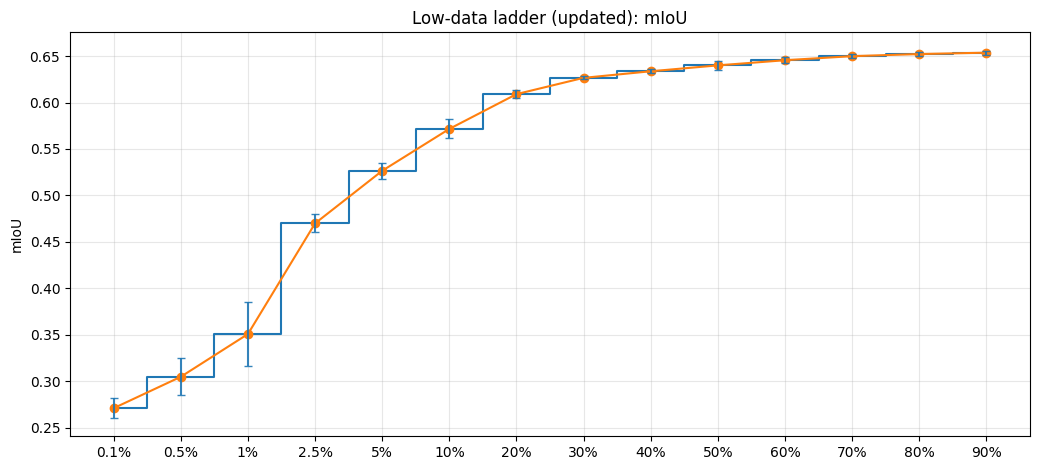

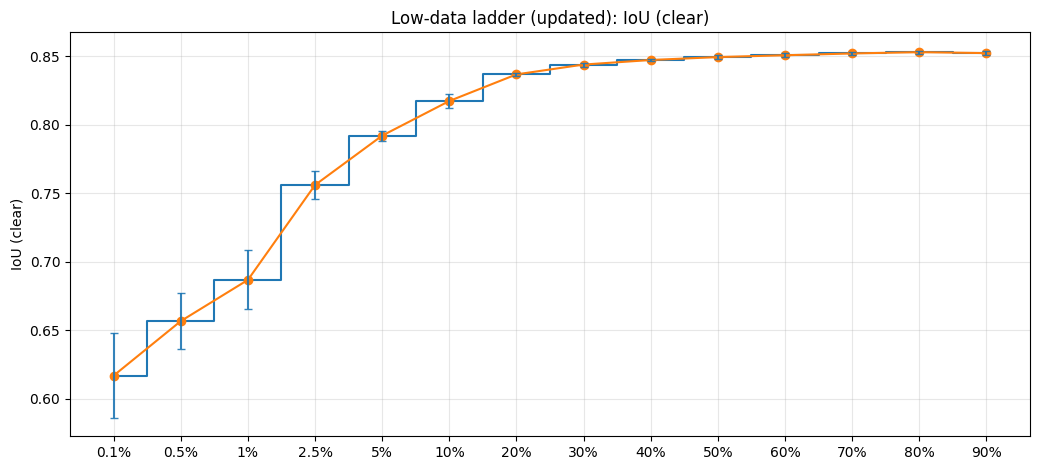

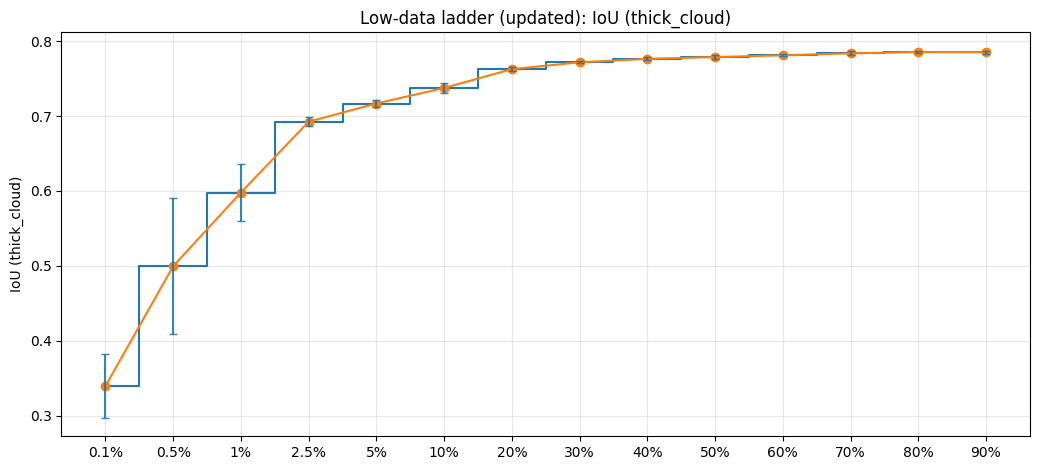

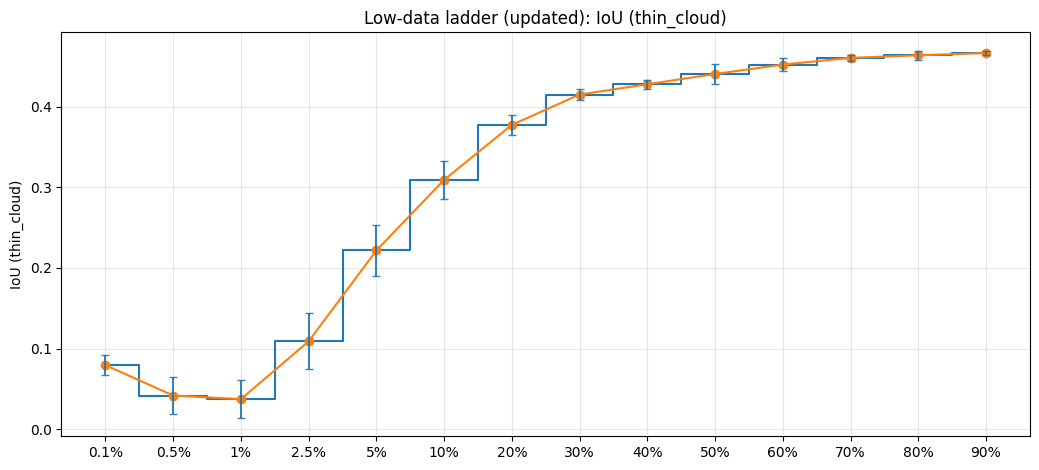

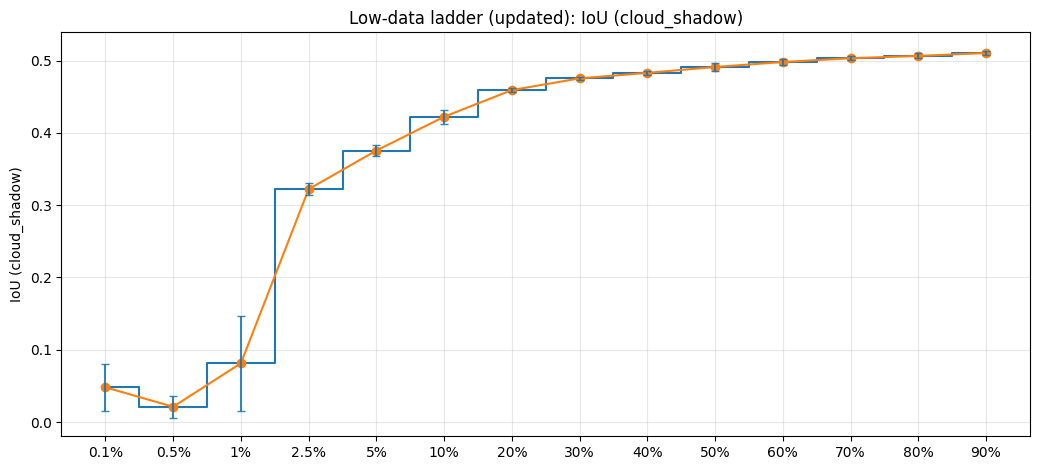

In [14]:
plot_ladder_df(dfp, "miou_mean", "miou_std",
               "Low-data ladder (updated): mIoU", "mIoU")

plot_ladder_df(dfp, "iou_clear_mean", "iou_clear_std",
               "Low-data ladder (updated): IoU (clear)", "IoU (clear)")

plot_ladder_df(dfp, "iou_thick_cloud_mean", "iou_thick_cloud_std",
               "Low-data ladder (updated): IoU (thick_cloud)", "IoU (thick_cloud)")

plot_ladder_df(dfp, "iou_thin_cloud_mean", "iou_thin_cloud_std",
               "Low-data ladder (updated): IoU (thin_cloud)", "IoU (thin_cloud)")

plot_ladder_df(dfp, "iou_cloud_shadow_mean", "iou_cloud_shadow_std",
               "Low-data ladder (updated): IoU (cloud_shadow)", "IoU (cloud_shadow)")

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv").expanduser().resolve()
if not ZS_MIOU_CSV.exists():
    raise FileNotFoundError(f"Missing ZS miou csv: {ZS_MIOU_CSV}")

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = zs_df[zs_df["id"] == "__aggregate__"]
if zs_agg.empty:
    raise ValueError("No __aggregate__ row in ZS miou csv")
zs_agg = zs_agg.iloc[0]

zs_row = {
    "pct": -1.0,
    "n_seeds": 1,
    "miou_mean": float(zs_agg["miou"]),
    "miou_std": 0.0,
    "iou_clear_mean": float(zs_agg["iou_clear"]),
    "iou_clear_std": 0.0,
    "iou_thick_cloud_mean": float(zs_agg["iou_thick_cloud"]),
    "iou_thick_cloud_std": 0.0,
    "iou_thin_cloud_mean": float(zs_agg["iou_thin_cloud"]),
    "iou_thin_cloud_std": 0.0,
    "iou_cloud_shadow_mean": float(zs_agg["iou_cloud_shadow"]),
    "iou_cloud_shadow_std": 0.0,
}

zs_dfp = pd.DataFrame([zs_row])

dfp_zs = pd.concat([zs_dfp, dfp], ignore_index=True)

dfp_zs = dfp_zs.sort_values("pct").reset_index(drop=True)
dfp_zs["x_label"] = dfp_zs["pct"].map(lambda x: "ZS" if x < 0 else f"{x:g}%")
dfp_zs["x"] = np.arange(len(dfp_zs))

display(dfp_zs[["pct","x_label","n_seeds","miou_mean","miou_std"]].head(10))


,pct,x_label,n_seeds,miou_mean,miou_std
0,-1.0,ZS,1,0.255040,0.000000
1,0.1,0.1%,10,0.270951,0.010473
2,0.5,0.5%,10,0.304765,0.019837
3,1.0,1%,10,0.350770,0.034354
4,2.5,2.5%,10,0.469882,0.009805
5,5.0,5%,10,0.526491,0.008548
6,10.0,10%,10,0.571587,0.010149
7,20.0,20%,10,0.609012,0.004018
8,30.0,30%,10,0.626551,0.001565
9,40.0,40%,10,0.633635,0.002077


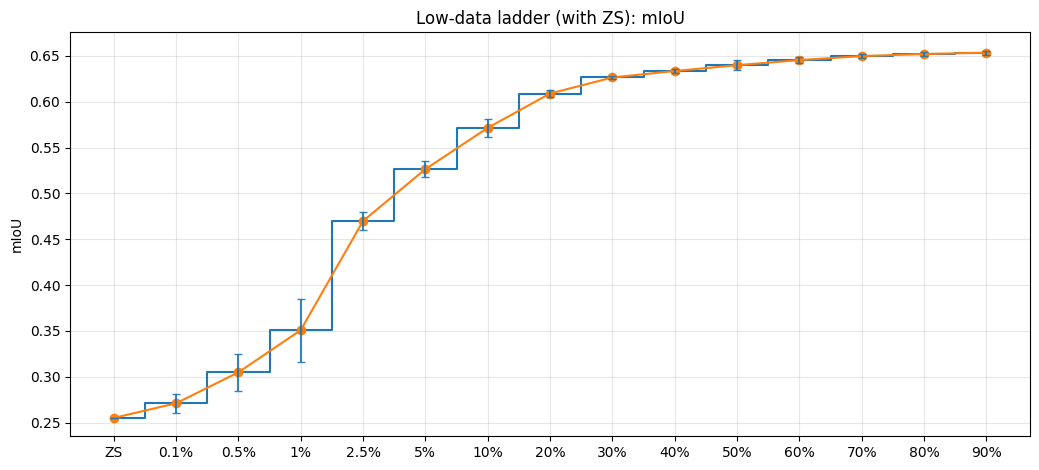

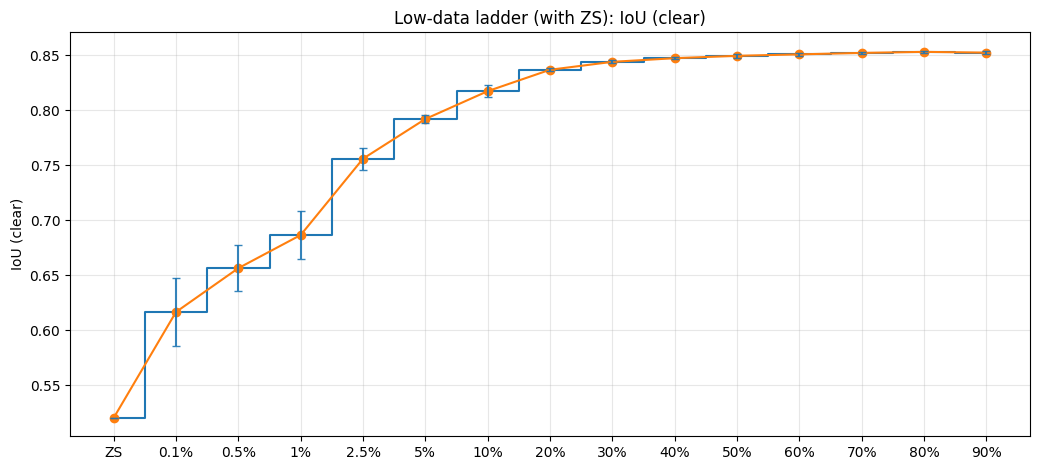

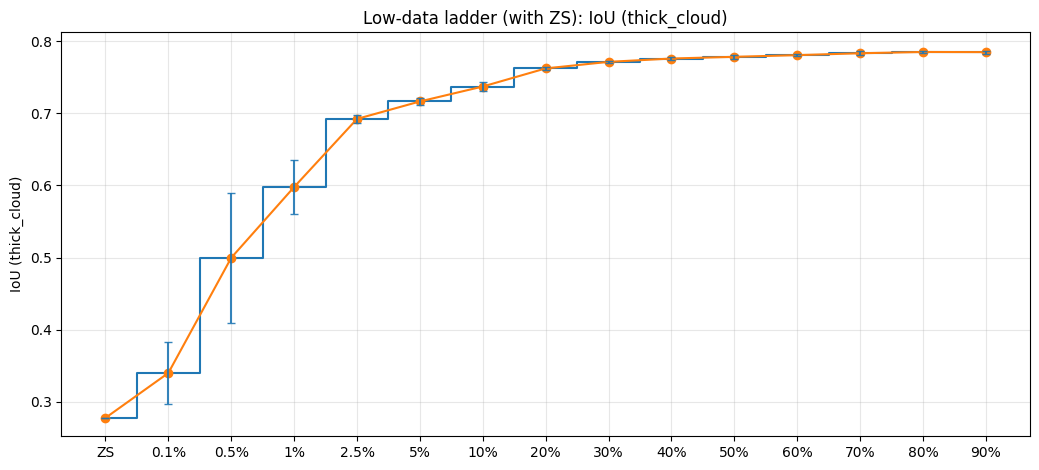

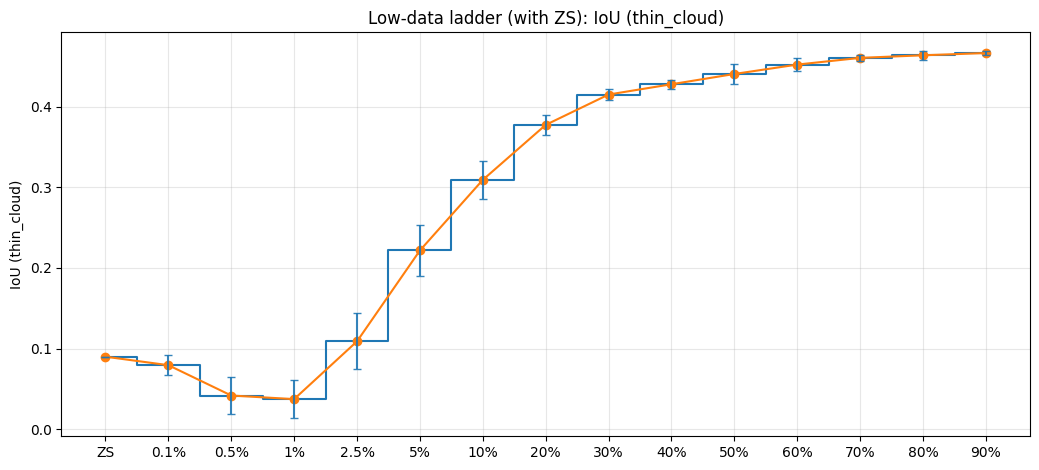

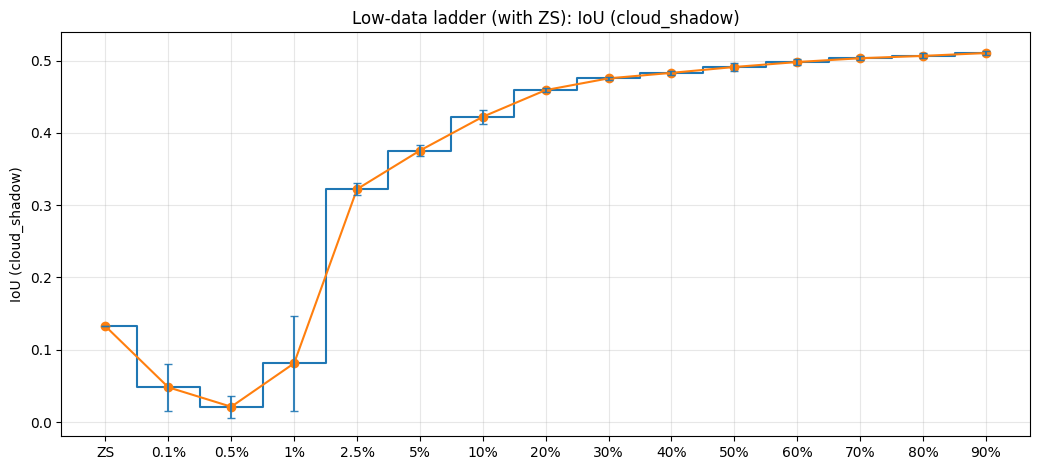

In [17]:
plot_ladder_df(dfp_zs, "miou_mean", "miou_std",
               "Low-data ladder (with ZS): mIoU", "mIoU")

plot_ladder_df(dfp_zs, "iou_clear_mean", "iou_clear_std",
               "Low-data ladder (with ZS): IoU (clear)", "IoU (clear)")

plot_ladder_df(dfp_zs, "iou_thick_cloud_mean", "iou_thick_cloud_std",
               "Low-data ladder (with ZS): IoU (thick_cloud)", "IoU (thick_cloud)")

plot_ladder_df(dfp_zs, "iou_thin_cloud_mean", "iou_thin_cloud_std",
               "Low-data ladder (with ZS): IoU (thin_cloud)", "IoU (thin_cloud)")

plot_ladder_df(dfp_zs, "iou_cloud_shadow_mean", "iou_cloud_shadow_std",
               "Low-data ladder (with ZS): IoU (cloud_shadow)", "IoU (cloud_shadow)")

In [19]:
RUNS_ROOT = Path("../inference/clipseg_cloudsen12plus_lora_low_data").expanduser().resolve()

OUT_ROOT = Path("../inference/clipseg_cloudsen12plus_lora_low_data").expanduser().resolve()

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").expanduser().resolve()


MODEL = "clipseg"
DATASET = "cloudsen12plus"


GT_KEY = "mask"
PRED_KEY = "mask"
GT_EXT = ".npz"
PRED_EXT = ".npz"

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

IGNORE_INDEX = None
STRICT = True
FORCE = False

BUCKETS = ["pct_2.5", "pct_20", "pct_30", "pct_40", "pct_60", "pct_70", "pct_80", "pct_90"]

EXISTING_LOW_DATA_CSV = Path("../inference/clipseg_cloudsen12plus_lora_low_data/lora_low_data_ladder.csv").expanduser().resolve()
print("RUNS_ROOT:", RUNS_ROOT, "exists:", RUNS_ROOT.exists())
print("OUT_ROOT :", OUT_ROOT, "exists:", OUT_ROOT.exists())
print("GT_DIR   :", GT_DIR, "exists:", GT_DIR.exists())
print("Existing low-data CSV:", EXISTING_LOW_DATA_CSV, "exists:", EXISTING_LOW_DATA_CSV.exists())

RUNS_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data exists: True
OUT_ROOT : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data exists: True
GT_DIR   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
Existing low-data CSV: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data/lora_low_data_ladder.csv exists: True


In [20]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

def parse_pct_value(folder_name: str) -> float:
    """
    pct_10  -> 10.0
    pct_0.1 -> 0.1
    """
    m = re.match(r"pct_(\d+(\.\d+)?)$", folder_name)
    if not m:
        raise ValueError(f"Bad pct folder name: {folder_name}")
    return float(m.group(1))

def sanitize_stage(s: str) -> str:
    s = s.strip()
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", s)

def pick_latest_checkpoint(seed_dir: Path) -> Path | None:
    ckpts = list(seed_dir.glob("checkpoint-*"))
    if not ckpts:
        return None
    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1
    ckpts.sort(key=step)
    return ckpts[-1]

def resolve_pred_dir(seed_dir: Path, pred_ext: str) -> Path:
    ckpt = pick_latest_checkpoint(seed_dir)
    if ckpt is not None:
        cand = ckpt / "masks"
        if cand.is_dir() and any(cand.glob(f"*{pred_ext}")):
            return cand

    cand2 = seed_dir / "masks"
    if cand2.is_dir() and any(cand2.glob(f"*{pred_ext}")):
        return cand2

    # fallback: best masks dir under seed
    candidates = [p for p in seed_dir.rglob("masks") if p.is_dir()]
    if candidates:
        candidates.sort(key=lambda p: len(list(p.glob(f"*{pred_ext}"))))
        best = candidates[-1]
        if any(best.glob(f"*{pred_ext}")):
            return best

    if any(seed_dir.glob(f"*{pred_ext}")):
        return seed_dir

    raise FileNotFoundError(f"Could not find prediction masks under: {seed_dir}")

def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)

def read_aggregate_row(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row in {csv_path}")
    return agg.iloc[0]


In [21]:
from pathlib import Path

if not RUNS_ROOT.exists():
    raise FileNotFoundError(f"RUNS_ROOT not found: {RUNS_ROOT}")
if not GT_DIR.exists():
    raise FileNotFoundError(f"GT_DIR not found: {GT_DIR}")

OUT_ROOT.mkdir(parents=True, exist_ok=True)

done = 0
skipped = 0
failed = 0

for pct_folder in BUCKETS:
    bucket_dir = (RUNS_ROOT / pct_folder).resolve()
    if not bucket_dir.is_dir():
        print(f"[WARN] Missing bucket folder: {bucket_dir} (skipping)")
        continue

    out_bucket_dir = (OUT_ROOT / pct_folder).resolve()
    out_bucket_dir.mkdir(parents=True, exist_ok=True)

    seed_dirs = sorted([s for s in bucket_dir.glob("seed_*") if s.is_dir()])
    print(f"\n[INFO] {pct_folder}: seeds={len(seed_dirs)}")

    for seed_dir in seed_dirs:
        seed_name = seed_dir.name

        miou_dst = out_bucket_dir / f"{seed_name}_miou.csv"
        cm_dst   = out_bucket_dir / f"{seed_name}_cm.csv"

        if (not FORCE) and miou_dst.exists() and cm_dst.exists():
            skipped += 1
            continue

        try:
            pred_dir = resolve_pred_dir(seed_dir, PRED_EXT)
            stage = sanitize_stage(seed_name)

            result = evaluate_segmentation(
                gt_dir=GT_DIR,
                pred_dir=pred_dir,
                model=MODEL,
                dataset=DATASET,
                stage=stage,
                num_classes=NUM_CLASSES,
                class_names=CLASS_NAMES,
                run_root=out_bucket_dir,
                gt_key=GT_KEY,
                pred_key=PRED_KEY,
                gt_ext=GT_EXT,
                pred_ext=PRED_EXT,
                ignore_index=IGNORE_INDEX,
                strict=STRICT,
            )

            safe_rename(Path(result["miou_csv"]), miou_dst)
            safe_rename(Path(result["cm_csv"]), cm_dst)

            done += 1
            print(f"[OK] {pct_folder}/{seed_name}")

        except Exception as e:
            failed += 1
            print(f"[FAIL] {pct_folder}/{seed_name}: {e}")

print(f"\n[DONE] ran={done}, skipped={skipped}, failed={failed}")



[INFO] pct_2.5: seeds=10


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_2.5/seed_11


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_2.5/seed_111


...

[OK] pct_90/seed_77


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_90/seed_88


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


[OK] pct_90/seed_99

[DONE] ran=80, skipped=0, failed=0


In [22]:
seed_records = []

for pct_folder in BUCKETS:
    out_bucket_dir = (OUT_ROOT / pct_folder).resolve()
    if not out_bucket_dir.is_dir():
        continue

    pct_val = parse_pct_value(pct_folder)

    miou_files = sorted(out_bucket_dir.glob("seed_*_miou.csv"))
    cm_files   = sorted(out_bucket_dir.glob("seed_*_cm.csv"))

    miou_map = {f.name.replace("_miou.csv",""): f for f in miou_files}
    cm_map   = {f.name.replace("_cm.csv",""): f for f in cm_files}

    seeds = sorted(set(miou_map.keys()) & set(cm_map.keys()))
    if not seeds:
        print(f"[WARN] No seed pairs in {out_bucket_dir}")
        continue

    for seed in seeds:
        miou_agg = read_aggregate_row(miou_map[seed])
        cm_agg   = read_aggregate_row(cm_map[seed])

        rec = {"pct": pct_val, "seed": seed, "bucket": pct_folder}

        for c in [c for c in miou_agg.index if c != "id"]:
            rec[c] = float(miou_agg[c])
        for c in [c for c in cm_agg.index if c != "id"]:
            rec[c] = int(cm_agg[c])

        seed_records.append(rec)

seed_df_new = pd.DataFrame(seed_records)
print("seed_df_new shape:", seed_df_new.shape)
display(seed_df_new.head())


seed_df_new shape: (80, 25)


,pct,seed,bucket,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow,cm_t0_p0,...,cm_t1_p2,cm_t1_p3,cm_t2_p0,cm_t2_p1,cm_t2_p2,cm_t2_p3,cm_t3_p0,cm_t3_p1,cm_t3_p2,cm_t3_p3
0,2.5,seed_11,pct_2.5,0.394081,0.742338,0.703089,0.641659,0.038639,0.192938,126102476,...,1165809,1221376,16199492,4247605,970452,567519,13530375,4796179,604932,5330217
1,2.5,seed_111,pct_2.5,0.394924,0.751982,0.712755,0.656397,0.010473,0.200072,126562714,...,228079,852361,16635966,4598389,239617,511096,12625969,6010027,185369,5440338
2,2.5,seed_22,pct_2.5,0.339193,0.719167,0.674650,0.597564,0.011446,0.073114,130084593,...,322471,241948,18059486,3578745,266798,80039,17625902,4350419,471189,1814193
3,2.5,seed_33,pct_2.5,0.384092,0.743352,0.703116,0.638401,0.020904,0.173945,128603154,...,431083,1057862,17179732,3847308,486415,471613,14084918,5209197,278426,4689162
4,2.5,seed_44,pct_2.5,0.311515,0.704792,0.661360,0.572157,0.006957,0.005587,130389066,...,443836,8896,18106882,3715920,161229,1037,19607376,4123644,395017,135666


In [23]:
if seed_df_new.empty:
    raise RuntimeError("No new seed records found for the BUCKETS. Check OUT_ROOT and file names.")

metric_cols = [c for c in seed_df_new.columns if c not in ["pct","seed","bucket"] and not c.startswith("cm_")]
cm_cols     = [c for c in seed_df_new.columns if c.startswith("cm_")]

n_seeds = seed_df_new.groupby("pct")["seed"].nunique().to_frame("n_seeds")
metric_mean = seed_df_new.groupby("pct")[metric_cols].mean().add_suffix("_mean")
metric_std  = seed_df_new.groupby("pct")[metric_cols].std(ddof=1).add_suffix("_std").fillna(0.0)
cm_sum      = seed_df_new.groupby("pct")[cm_cols].sum().add_suffix("_sum")

pct_df_new = pd.concat([n_seeds, metric_mean, metric_std, cm_sum], axis=1).reset_index().sort_values("pct")
display(pct_df_new)

if EXISTING_LOW_DATA_CSV.exists():
    old = pd.read_csv(EXISTING_LOW_DATA_CSV)
    if "pct" not in old.columns:
        raise ValueError("Existing low_data_ladder.csv must have a 'pct' column")

    old["pct"] = old["pct"].astype(float)
    pct_df_new["pct"] = pct_df_new["pct"].astype(float)

    old_i = old.set_index("pct")
    new_i = pct_df_new.set_index("pct")

    old_i.update(new_i)
    merged = pd.concat([old_i, new_i[~new_i.index.isin(old_i.index)]], axis=0).reset_index()
    merged = merged.sort_values("pct")

    bak = EXISTING_LOW_DATA_CSV.with_suffix(".csv.bak")
    bak.write_text(EXISTING_LOW_DATA_CSV.read_text())
    print("[INFO] backup:", bak)

    merged.to_csv(EXISTING_LOW_DATA_CSV, index=False)
    print("[DONE] updated:", EXISTING_LOW_DATA_CSV)

    low_data_final = merged
else:
    EXISTING_LOW_DATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    pct_df_new.to_csv(EXISTING_LOW_DATA_CSV, index=False)
    print("[DONE] wrote new:", EXISTING_LOW_DATA_CSV)
    low_data_final = pct_df_new

display(low_data_final)


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,2.5,10,0.363673,0.725828,0.686757,0.601972,0.028579,0.137384,0.059670,0.035521,...,7195743,7888768,169272923,39044740,7304803,4228214,152090534,47221961,4581717,38722818
1,20.0,10,0.523722,0.802485,0.784234,0.708964,0.223207,0.378483,0.015830,0.008815,...,22073458,30936777,104851596,41724199,61489606,11785279,67583838,43948151,9767066,121317975
2,30.0,10,0.540855,0.813776,0.796951,0.723074,0.248287,0.395106,0.009687,0.005795,...,19374870,28947538,99463180,43412656,66224892,10749952,67179967,42056545,9152915,124227603
3,40.0,10,0.545029,0.816912,0.800151,0.727683,0.252892,0.399389,0.025609,0.009746,...,18445858,29428559,99938526,41842697,66857317,11212140,67712527,40985165,7874696,126044642
4,60.0,10,0.578668,0.830064,0.816355,0.740301,0.335024,0.422990,0.013973,0.005224,...,22541603,28593488,78616540,39171559,91838141,10224440,61181867,39529997,9154253,132750913
5,70.0,10,0.584548,0.833209,0.820330,0.744362,0.344261,0.429239,0.013187,0.004757,...,20987575,28939067,75143517,40696448,93789413,10221302,59920406,39271693,8699293,134725638
6,80.0,10,0.586059,0.833780,0.820112,0.744692,0.349074,0.430357,0.016755,0.005304,...,20679158,28863670,74982660,39565264,95066198,10236558,60752729,38619166,8393025,134852110
7,90.0,10,0.595164,0.837171,0.823310,0.748720,0.370714,0.437912,0.008531,0.002492,...,22044656,29328120,71085619,37262177,101582013,9920871,60621125,36108496,8586828,137300581


[INFO] backup: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data/lora_low_data_ladder.csv.bak
[DONE] updated: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data/lora_low_data_ladder.csv


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,0.1,10,0.269219,0.534832,0.587705,0.318992,0.091431,0.078748,0.009396,0.027644,...,308788311,39781954,90256679,25830315,78304771,25458915,112528845,27988530,73067755,29031900
1,0.5,10,0.262399,0.626186,0.619056,0.386373,0.034816,0.009353,0.009344,0.039632,...,102313866,5315626,176227291,19564566,21161162,2897661,190184750,26133184,23734175,2564921
2,1.0,10,0.301695,0.690638,0.649085,0.529780,0.012980,0.014936,0.014967,0.013746,...,9013455,634984,188153056,28344260,3217394,135970,198156741,35798273,5019364,3642652
6,2.5,10,0.363673,0.725828,0.686757,0.601972,0.028579,0.137384,0.059670,0.035521,...,7195743,7888768,169272923,39044740,7304803,4228214,152090534,47221961,4581717,38722818
3,5.0,10,0.434950,0.755622,0.727147,0.649003,0.093332,0.270318,0.064952,0.039541,...,15730907,24267387,140162836,43333273,25388565,10966006,100725925,49426679,6544056,85920370
4,10.0,10,0.482495,0.784513,0.759561,0.691488,0.146401,0.332530,0.021771,0.008712,...,16299288,26867639,125660220,43789851,38852213,11548396,82309352,49409255,6561926,104336497
7,20.0,10,0.523722,0.802485,0.784234,0.708964,0.223207,0.378483,0.015830,0.008815,...,22073458,30936777,104851596,41724199,61489606,11785279,67583838,43948151,9767066,121317975
8,30.0,10,0.540855,0.813776,0.796951,0.723074,0.248287,0.395106,0.009687,0.005795,...,19374870,28947538,99463180,43412656,66224892,10749952,67179967,42056545,9152915,124227603
9,40.0,10,0.545029,0.816912,0.800151,0.727683,0.252892,0.399389,0.025609,0.009746,...,18445858,29428559,99938526,41842697,66857317,11212140,67712527,40985165,7874696,126044642
5,50.0,10,0.564985,0.822402,0.808165,0.730722,0.305998,0.415056,0.019513,0.010042,...,19983225,30564529,81079197,43030621,83644884,12095978,58539814,41370412,9043372,133663432


In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "low_data_final" in globals() and isinstance(low_data_final, pd.DataFrame) and not low_data_final.empty:
    dfp = low_data_final.copy()
else:
    LOW_DATA_CSV = Path("./low_data_ladder.csv").expanduser().resolve()
    if not LOW_DATA_CSV.exists():
        raise FileNotFoundError("Neither low_data_final exists nor ./low_data_ladder.csv found")
    dfp = pd.read_csv(LOW_DATA_CSV)

dfp["pct"] = dfp["pct"].astype(float)
dfp = dfp.sort_values("pct").reset_index(drop=True)

dfp["x_label"] = dfp["pct"].map(lambda x: f"{x:g}%")
dfp["x"] = np.arange(len(dfp))

display(dfp[["pct","x_label","n_seeds","miou_mean","miou_std"]].head(20))


,pct,x_label,n_seeds,miou_mean,miou_std
0,0.1,0.1%,10,0.269219,0.009396
1,0.5,0.5%,10,0.262399,0.009344
2,1.0,1%,10,0.301695,0.014967
3,2.5,2.5%,10,0.363673,0.059670
4,5.0,5%,10,0.434950,0.064952
5,10.0,10%,10,0.482495,0.021771
6,20.0,20%,10,0.523722,0.015830
7,30.0,30%,10,0.540855,0.009687
8,40.0,40%,10,0.545029,0.025609
9,50.0,50%,10,0.564985,0.019513


In [25]:
def plot_ladder_df(df: pd.DataFrame, mean_col: str, std_col: str, title: str, ylabel: str):
    x = df["x"].to_numpy()
    y = df[mean_col].astype(float).to_numpy()
    yerr = df[std_col].astype(float).to_numpy() if std_col in df.columns else None

    plt.figure(figsize=(10.5, 4.8))
    plt.step(x, y, where="mid")
    plt.plot(x, y, marker="o")

    if yerr is not None:
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3, alpha=0.9)

    plt.xticks(x, df["x_label"].tolist())
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [26]:
from pathlib import Path
import pandas as pd
import numpy as np

ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv").expanduser().resolve()
if not ZS_MIOU_CSV.exists():
    raise FileNotFoundError(f"Missing ZS miou csv: {ZS_MIOU_CSV}")

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = zs_df[zs_df["id"] == "__aggregate__"]
if zs_agg.empty:
    raise ValueError("No __aggregate__ row in ZS miou csv")
zs_agg = zs_agg.iloc[0]

zs_row = {
    "pct": -1.0,
    "n_seeds": 1,
    "miou_mean": float(zs_agg["miou"]),
    "miou_std": 0.0,
    "iou_clear_mean": float(zs_agg["iou_clear"]),
    "iou_clear_std": 0.0,
    "iou_thick_cloud_mean": float(zs_agg["iou_thick_cloud"]),
    "iou_thick_cloud_std": 0.0,
    "iou_thin_cloud_mean": float(zs_agg["iou_thin_cloud"]),
    "iou_thin_cloud_std": 0.0,
    "iou_cloud_shadow_mean": float(zs_agg["iou_cloud_shadow"]),
    "iou_cloud_shadow_std": 0.0,
}

zs_dfp = pd.DataFrame([zs_row])

dfp_zs = pd.concat([zs_dfp, dfp], ignore_index=True)

dfp_zs = dfp_zs.sort_values("pct").reset_index(drop=True)
dfp_zs["x_label"] = dfp_zs["pct"].map(lambda x: "ZS" if x < 0 else f"{x:g}%")
dfp_zs["x"] = np.arange(len(dfp_zs))

display(dfp_zs[["pct","x_label","n_seeds","miou_mean","miou_std"]].head(10))


,pct,x_label,n_seeds,miou_mean,miou_std
0,-1.0,ZS,1,0.255040,0.000000
1,0.1,0.1%,10,0.269219,0.009396
2,0.5,0.5%,10,0.262399,0.009344
3,1.0,1%,10,0.301695,0.014967
4,2.5,2.5%,10,0.363673,0.059670
5,5.0,5%,10,0.434950,0.064952
6,10.0,10%,10,0.482495,0.021771
7,20.0,20%,10,0.523722,0.015830
8,30.0,30%,10,0.540855,0.009687
9,40.0,40%,10,0.545029,0.025609


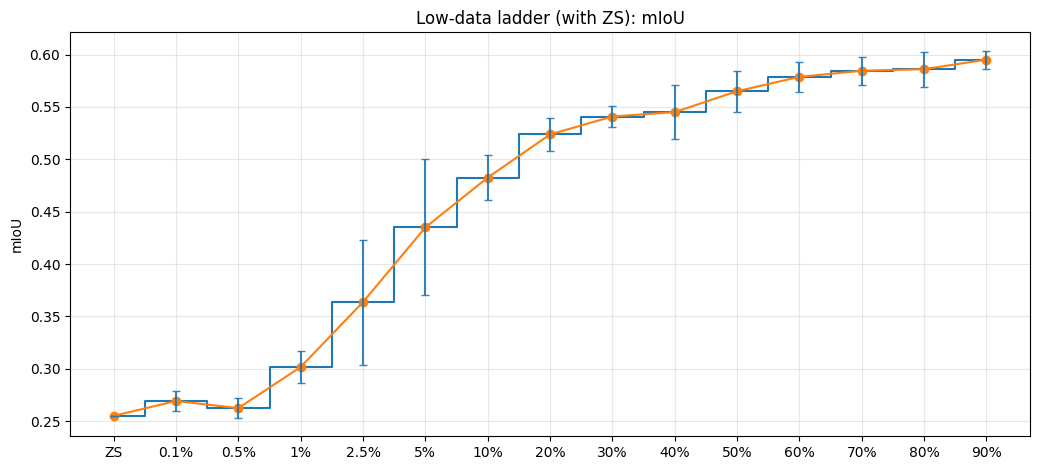

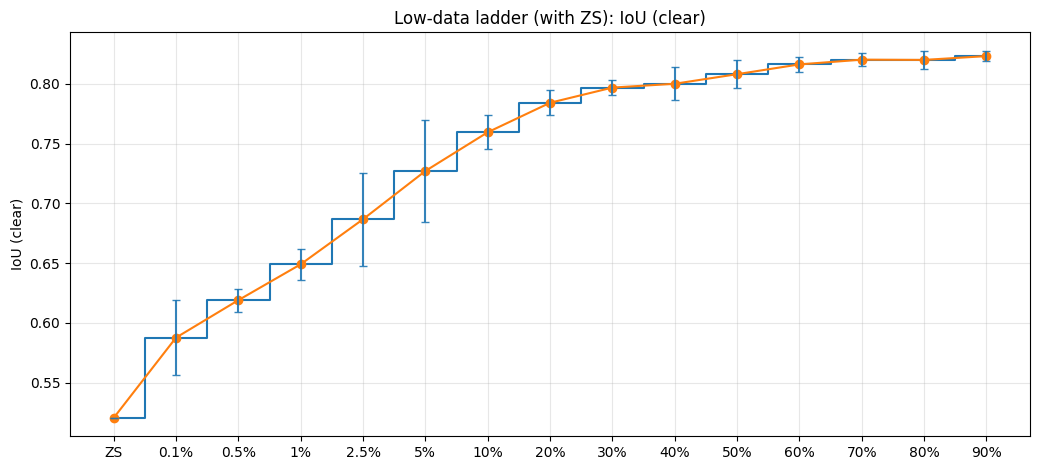

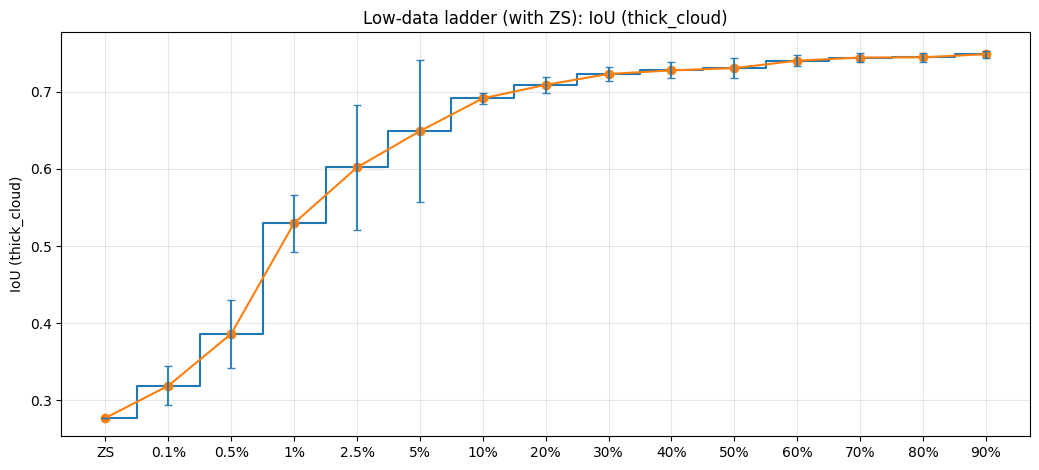

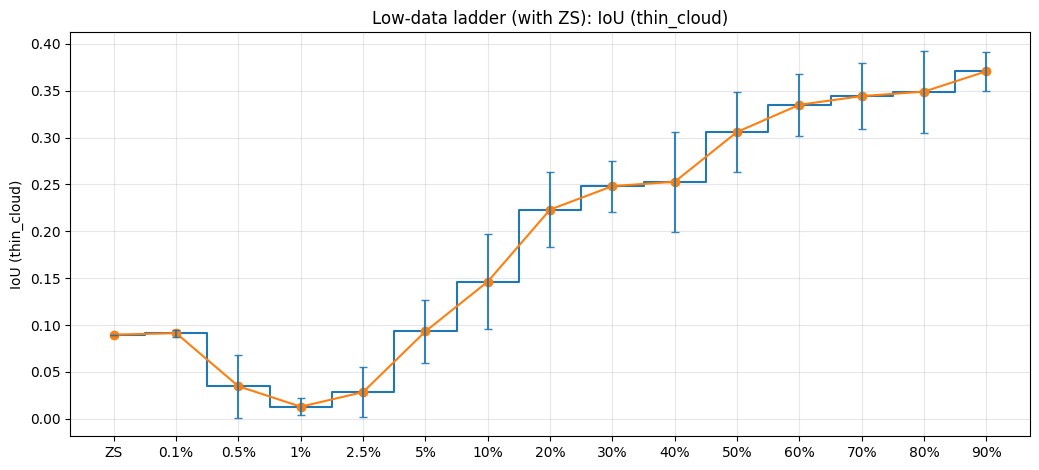

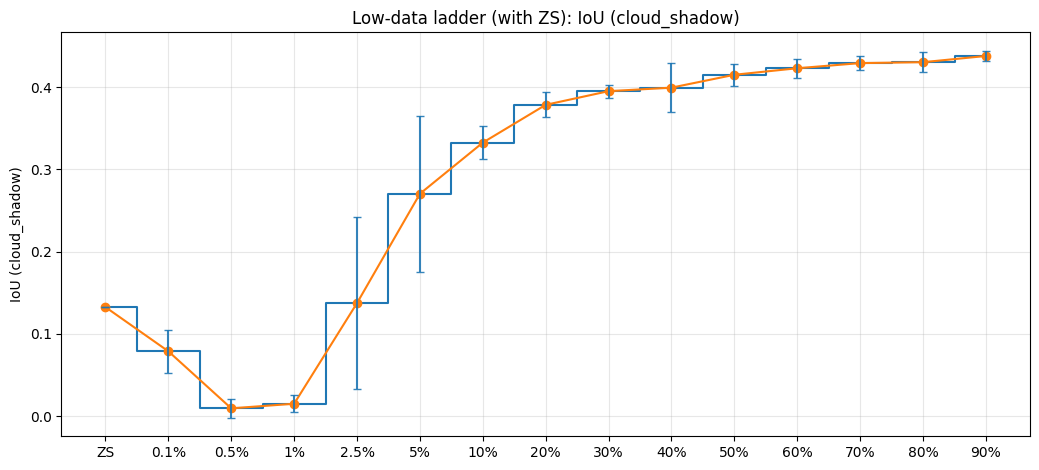

In [27]:
plot_ladder_df(dfp_zs, "miou_mean", "miou_std",
               "Low-data ladder (with ZS): mIoU", "mIoU")

plot_ladder_df(dfp_zs, "iou_clear_mean", "iou_clear_std",
               "Low-data ladder (with ZS): IoU (clear)", "IoU (clear)")

plot_ladder_df(dfp_zs, "iou_thick_cloud_mean", "iou_thick_cloud_std",
               "Low-data ladder (with ZS): IoU (thick_cloud)", "IoU (thick_cloud)")

plot_ladder_df(dfp_zs, "iou_thin_cloud_mean", "iou_thin_cloud_std",
               "Low-data ladder (with ZS): IoU (thin_cloud)", "IoU (thin_cloud)")

plot_ladder_df(dfp_zs, "iou_cloud_shadow_mean", "iou_cloud_shadow_std",
               "Low-data ladder (with ZS): IoU (cloud_shadow)", "IoU (cloud_shadow)")